In [1]:
import math
import pandas as pd

rho_l = 1198   # TPU (Thermoplastic Polyurethane) Sort
rho_h = 1504   # POM Orange
C = 0.15       # volumefraktion i bed (antagelse)

# [c, b, a, m] 
data_POM = [
    [3.55, 6.27, 8.28, 0.1213],
    [5.78, 5.77, 6.40, 0.1131],
    [5.30, 6.23, 10.51, 0.3064],
    [5.20, 5.72, 8.27, 0.1547],
    [5.27, 5.97, 8.26, 0.1658],
    [4.16, 4.96, 7.34, 0.0810],
    [5.49, 6.03, 7.74, 0.1520],
    [4.53, 5.06, 9.67, 0.1288],
    [4.63, 6.62, 8.39, 0.1655],
    [3.34, 5.35, 7.14, 0.0689],
    [5.47, 4.35, 7.29, 0.0555],
    [3.79, 5.72, 7.89, 0.1073],
    [3.27, 4.09, 6.79, 0.0545],
    [3.34, 5.62, 7.30, 0.0823],
    [4.50, 5.05, 7.59, 0.0939],
]

data_TPU = [
    [2.09, 5.39, 8.95, 0.0517],
    [1.94, 4.15, 9.04, 0.0380],
    [2.04, 5.43, 9.50, 0.0527],
    [3.31, 5.16, 9.15, 0.0746],
    [2.18, 5.00, 6.06, 0.0305],
    [2.25, 7.38, 13.80, 0.1301],
    [2.28, 6.64, 9.89, 0.0873],
    [2.22, 7.07, 9.79, 0.9890],
    [3.09, 8.19, 13.60, 0.1885],
    [2.09, 8.41, 9.95, 0.1094],
    [2.20, 4.86, 6.73, 0.0342],
    [2.11, 6.20, 10.11, 0.0588],
    [3.14, 5.54, 10.81, 0.0734],
    [2.26, 4.63, 10.99, 0.0554],
    [2.08, 7.87, 10.50, 0.1426],
]

data_heavy_1_8 = [
    [2.17, 6.11, 8.66, 0.0585],
    [2.73, 3.29, 7.20, 0.0636],
    [3.78, 5.08, 7.76, 0.0692],
    [3.15, 5.50, 8.97, 0.0890],
    [3.63, 4.31, 7.95, 0.0919],
    [3.02, 4.01, 6.21, 0.0560],
    [3.61, 3.91, 6.77, 0.0669],
    [3.20, 4.26, 5.98, 0.0455],
    [3.87, 4.49, 6.96, 0.0764],
    [2.79, 4.00, 7.81, 0.0550],
    [3.16, 3.79, 5.52, 0.0380],
    [2.92, 3.42, 5.76, 0.0438],
    [3.11, 3.90, 5.21, 0.0433],
    [4.00, 4.40, 10.62, 0.0682],
    [3.48, 4.17, 7.55, 0.0081],
    [3.20, 3.87, 5.48, 0.0429],
    [3.53, 3.99, 6.53, 0.0623],
    [3.38, 3.85, 7.94, 0.0766],
    [3.76, 4.17, 5.80, 0.0479],
    [3.89, 5.84, 7.15, 0.0625],
    [2.90, 4.20, 7.88, 0.0650],
    [3.23, 4.07, 9.58, 0.0755],
    [2.43, 3.30, 4.80, 0.0232],
    [2.66, 4.19, 6.31, 0.0467],
    [3.29, 3.90, 7.33, 0.0640]
]

data_heavy_4 = [
    [3.51, 4.93, 6.24, 0.0782],
    [4.23, 5.54, 6.33, 0.0954],
    [3.35, 6.44, 9.67, 0.1549],
    [3.17, 5.58, 9.02, 0.0872],
    [3.78, 6.28, 6.88, 0.0998],
    [4.14, 5.36, 5.69, 0.1034],
    [3.64, 6.77, 7.38, 0.0929],
    [4.48, 5.09, 7.18, 0.1192],
    [4.52, 6.51, 10.56, 0.1870],
    [5.70, 5.84, 7.65, 0.1611],
    [4.30, 5.38, 6.53, 0.0947],
    [5.79, 6.71, 8.61, 0.1719],
    [5.18, 5.53, 8.62, 0.1755],
    [5.25, 5.98, 8.19, 0.1525],
    [4.02, 6.66, 10.09, 0.1576],
    [3.45, 5.06, 7.81, 0.0941],
    [3.75, 7.63, 9.37, 0.1814],
    [5.10, 7.55, 11.78, 0.2169],
    [4.43, 6.13, 7.34, 0.1252],
    [4.35, 5.28, 8.46, 0.1401],
    [3.09, 5.46, 8.22, 0.0731],
    [5.56, 5.63, 7.77, 0.1517],
    [4.48, 6.60, 7.58, 0.1384],
    [5.23, 5.78, 8.64, 0.1769],
    [4.22, 5.83, 8.76, 0.1360]
]

data_heavy_6_3 = [
    [5.84, 7.21, 9.04, 0.2518],
    [5.72, 10.15, 15.55, 0.4969],
    [5.27, 9.22, 11.30, 0.3411],
    [5.54, 6.52, 9.31, 0.2426],
    [5.54, 7.67, 10.80, 0.2982],
    [5.73, 9.61, 11.17, 0.4174],
    [5.04, 5.28, 11.08, 0.2255],
    [5.17, 9.54, 9.98, 0.2754],
    [5.04, 8.11, 10.28, 0.2747],
    [4.79, 9.13, 11.42, 0.1999],
    [5.92, 6.56, 12.21, 0.2557],
    [5.51, 7.22, 10.46, 0.2522],
    [5.89, 7.98, 10.18, 0.3147],
    [5.80, 6.93, 11.09, 0.2900],
    [5.41, 6.71, 10.67, 0.2875],
    [6.93, 9.25, 12.06, 0.3792],
    [6.07, 7.41, 10.74, 0.3279],
    [4.56, 7.74, 11.06, 0.2452],
    [5.46, 8.05, 9.21, 0.2625],
    [4.87, 8.50, 12.64, 0.3077],
    [5.44, 7.11, 9.37, 0.2200],
    [5.71, 7.19, 8.80, 0.2465],
    [5.50, 7.44, 10.08, 0.3035],
    [5.43, 7.25, 10.34, 0.2730],
    [5.30, 7.51, 11.13, 0.3447]
]

data_light_1_8 = [
   [2.10, 4.95, 9.44, 0.0505],
    [2.11, 4.61, 7.31, 0.0462],
    [2.15, 4.71, 9.24, 0.0386],
    [2.16, 4.06, 8.95, 0.0498],
    [2.23, 4.08, 9.83, 0.0526],
    [2.44, 4.78, 11.11, 0.0344],
    [2.19, 4.11, 6.98, 0.0359],
    [2.27, 3.79, 6.90, 0.0320],
    [2.16, 5.23, 9.02, 0.0333],
    [2.07, 3.57, 7.85, 0.0282],
    [2.37, 4.37, 7.76, 0.0428],
    [1.19, 2.78, 11.33, 0.0308],
    [2.21, 4.45, 7.17, 0.0364],
    [3.22, 4.92, 9.73, 0.0553],
    [2.77, 3.66, 9.81, 0.0652],
    [2.85, 3.47, 7.36, 0.0338],
    [2.63, 4.24, 6.70, 0.0405],
    [2.06, 4.42, 11.54, 0.0813],
    [2.26, 4.53, 8.70, 0.0520],
    [2.10, 4.46, 7.92, 0.0433],
    [2.58, 3.68, 13.89, 0.0772],
    [2.53, 2.66, 8.83, 0.0282],
    [3.18, 3.60, 6.04, 0.0403],
    [2.94, 3.00, 8.30, 0.0288],
    [2.16, 4.96, 9.28, 0.0497]
]

data_light_4 = [
    [2.51, 7.48, 12.92, 0.1101],
    [2.23, 7.04, 10.79, 0.0680],
    [2.00, 4.95, 6.08, 0.0399],
    [2.43, 8.04, 12.22, 0.1399],
    [2.22, 4.99, 7.44, 0.0582],
    [3.29, 5.58, 9.49, 0.0840],
    [2.20, 6.13, 8.62, 0.0882],
    [2.18, 7.00, 12.94, 0.1094],
    [2.16, 5.67, 10.55, 0.0772],
    [2.11, 5.47, 9.68, 0.0735],
    [2.23, 4.40, 8.88, 0.0496],
    [2.09, 6.19, 7.99, 0.0495],
    [3.34, 7.79, 11.06, 0.1136],
    [2.24, 5.17, 7.72, 0.0569],
    [3.19, 9.72, 11.66, 0.0947],
    [2.14, 6.18, 8.48, 0.0603],
    [2.71, 7.22, 9.86, 0.0886],
    [2.15, 6.97, 10.93, 0.0775],
    [1.48, 5.86, 9.76, 0.0489],
    [2.18, 6.89, 11.00, 0.0940],
    [2.19, 5.92, 9.80, 0.0625],
    [2.14, 7.06, 9.77, 0.0789],
    [2.22, 4.28, 10.40, 0.0703],
    [2.17, 5.27, 9.21, 0.0597],
    [2.29, 5.96, 11.14, 0.0816],
]

data_light_6_3 = [
    [2.19, 9.27, 10.62, 0.1205],
    [2.14, 10.78, 12.96, 0.1785],
    [2.45, 8.29, 10.85, 0.1429],
    [2.28, 11.29, 12.99, 0.2040],
    [2.27, 9.56, 14.26, 0.1893],
    [2.25, 9.04, 11.58, 0.1522],
    [2.22, 7.68, 12.65, 0.1134],
    [2.22, 7.57, 10.94, 0.1275],
    [2.32, 8.28, 14.02, 0.1492],
    [2.21, 8.85, 10.65, 0.1162],
    [2.26, 9.71, 13.55, 0.1836],
    [2.13, 8.83, 10.19, 0.1182],
    [2.12, 9.46, 15.84, 0.2063],
    [2.12, 8.07, 14.80, 0.1470],
    [2.21, 10.80, 13.98, 0.1450],
    [2.27, 9.69, 16.87, 0.2332],
    [2.21, 8.30, 11.33, 0.1320],
    [3.28, 7.99, 11.79, 0.1280],
    [2.24, 9.14, 10.27, 0.1189],
    [2.40, 8.01, 11.61, 0.1295],
    [2.21, 8.34, 13.37, 0.1426],
    [2.18, 7.64, 11.12, 0.1121],
    [2.19, 9.10, 12.60, 0.1405],
    [2.27, 9.03, 11.96, 0.1342],
    [3.19, 8.26, 11.35, 0.0970],
]

data_light = data_light_6_3 + data_light_4 + data_light_1_8
data_heavy = data_heavy_6_3 + data_heavy_4 + data_heavy_1_8
rho_f = 998.2        # Vand [kg/m3]
mu    = 1.0016e-3    # [Pa*s]
nu    = mu / rho_f   # [m^2/s]
g     = 9.82         # [m/s2]

def Cd_Goral(Re, psi):
    Gamma = 1 + (3.2 / math.sqrt(Re)) + (32 / Re)
    Ypsilon = min(0.44*psi**-2, 1) 
    return Gamma * Ypsilon


def terminal_velocity_Goral(a, b, c, m, psi, rho_p, dD, v0=0.05, iters=100): 
    s = rho_p / rho_f                     # Relativ densitet af partiklen
    V = m / rho_p                         # Volumen 
    dp = math.sqrt(a*b)                   # Karakteristiske længde for en irregulær partikel
    dV = (6*V / math.pi)**(1/3)           # Volumenækvivalent diameter
    dn = (a*b*c)**(1/3)                   # Nominal diameter

    if dD == "dV":
        dD = dV
    elif dD == "dn":
        dD = dn
    elif dD == "c":
        dD = c
    elif dD == "dp":
        dD = dp    

    v = v0
    for _ in range(iters):    
        Re = dp*v / nu
        Cd = Cd_Goral(Re, psi)
        v = math.sqrt((4 * g * (s-1) * dD) / (3 * Cd)) 
    Re = dp*v / nu
    Cd = Cd_Goral(Re, psi)
    return v, Re, Cd, V

def n_richardson_zaki(Re):
    if Re < 1:
        return 4.65
    elif Re < 1000:
        return 4.45*(Re**(-0.1))
    else:
        return 2.39

def build_df_from_matrix(data_mm):
    df = pd.DataFrame(data_mm, columns=["c","b","a","m"]) / 1000 # Milimeter til meter
    df["psi"] = (df["c"]**2/(df["b"]*df["a"]))**(1/3)
    df["c_mm"] = df["c"] * 1000     # Meter til milimeter
    df["b_mm"] = df["b"] * 1000     # Meter til milimeter
    df["a_mm"] = df["a"] * 1000     # Meter til milimeter
    df["m_gram"] = df["m"] * 1000   # Meter til milimeter
    return df

def calculate(data_mm, rho_p, C, dD):
    df = build_df_from_matrix(data_mm)
    v_list, Re_list, Cd_list, vh_list, V_list, dn_list, dV_list = [], [], [], [], [], [], []
    for _, r in df.iterrows():
        v, Re, Cd, V = terminal_velocity_Goral(r["a"], r["b"], r["c"], r["m"], r["psi"], rho_p, dD) 
        n = n_richardson_zaki(Re)
        vh = v*((1-C)**n)
        dn = (r["a"] * r["b"] * r["c"])**(1/3) * 1000 # Meter til milimeter
        dV = (6*V / math.pi)**(1/3) * 1000            # Meter til milimeter
        V *= 10**6                                    # m^3 til cm^3
        v_list.append(v); Re_list.append(Re); Cd_list.append(Cd); vh_list.append(vh); V_list.append(V); dn_list.append(dn); dV_list.append(dV)

    df[f"v_single_m/s"]   = v_list
    df[f"v_hindered_m/s"] = vh_list
    df[f"Re"]             = Re_list
    df[f"Cd"]             = Cd_list
    df[f"V_cm^3"]         = V_list
    df[f"dn_mm"]          = dn_list
    df[f"dV_mm"]          = dV_list
    return df

># Terminalhastighed med dV

In [2]:
df_light = calculate(data_light, rho_p=rho_l, C=C, dD = "dV")
df_heavy = calculate(data_heavy, rho_p=rho_h, C=C, dD = "dV")

cols = ["psi","Re","Cd","v_single_m/s","v_hindered_m/s", "a_mm", "b_mm", "c_mm", "m_gram", "V_cm^3", "dn_mm", "dV_mm"]

for df, label in [(df_light, "LIGHT (TPU)"), (df_heavy, "HEAVY (POM)")]:
    d = df[cols].reset_index(drop=True)
    d.index += 1
    d.loc["Mean"] = d.mean()
    styled = (d.style.format("{:.4f}").set_caption(label)
               .set_properties(subset=pd.IndexSlice["Mean", :], **{"font-weight": "bold"}))
    display(styled)

,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.3652,1147.8028,1.1223,0.1161,0.0787,10.6200,9.2700,2.1900,0.1205,0.1006,5.9963,5.7700
2,0.3200,1471.1706,1.1052,0.1249,0.0847,12.9600,10.7800,2.1400,0.1785,0.1490,6.6867,6.5775
3,0.4056,1128.0935,1.1236,0.1194,0.0809,10.8500,8.2900,2.4500,0.1429,0.1193,6.0402,6.1074
4,0.3285,1543.3214,1.1022,0.1279,0.0867,12.9900,11.2900,2.2800,0.2040,0.1703,6.9408,6.8769
5,0.3356,1467.4396,1.1053,0.1261,0.0855,14.2600,9.5600,2.2700,0.1893,0.1580,6.7640,6.7076
6,0.3643,1233.4780,1.1171,0.1210,0.0820,11.5800,9.0400,2.2500,0.1522,0.1270,6.1757,6.2372
7,0.3702,1128.0860,1.1236,0.1148,0.0779,12.6500,7.6800,2.2200,0.1134,0.0947,5.9970,5.6544
8,0.3904,1059.7918,1.1285,0.1169,0.0792,10.9400,7.5700,2.2200,0.1275,0.1064,5.6862,5.8797
9,0.3593,1296.6560,1.1135,0.1208,0.0819,14.0200,8.2800,2.3200,0.1492,0.1245,6.4579,6.1959
10,0.3728,1115.2165,1.1245,0.1153,0.0782,10.6500,8.8500,2.2100,0.1162,0.0970,5.9278,5.7006


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.8058,1996.2669,0.7370,0.2481,0.1682,9.0400,7.2100,5.8400,0.2518,0.1674,7.2472,6.8381
2,0.5918,2886.5192,1.0706,0.2305,0.1563,15.5500,10.1500,5.7200,0.4969,0.3304,9.6649,8.5771
3,0.6436,2190.0836,1.0830,0.2153,0.1460,11.3000,9.2200,5.2700,0.3411,0.2268,8.1885,7.5662
4,0.7967,1890.2998,0.7560,0.2434,0.1651,9.3100,6.5200,5.5400,0.2426,0.1613,6.9540,6.7538
5,0.7182,2064.8596,0.9262,0.2276,0.1544,10.8000,7.6700,5.5400,0.2982,0.1983,7.7133,7.2347
6,0.6738,2338.6779,1.0466,0.2265,0.1536,11.1700,9.6100,5.7300,0.4174,0.2775,8.5044,8.0929
7,0.7572,1738.8687,0.8404,0.2281,0.1547,11.0800,5.2800,5.0400,0.2255,0.1499,6.6558,6.5912
8,0.6548,2016.4164,1.0871,0.2074,0.1406,9.9800,9.5400,5.1700,0.2754,0.1831,7.8957,7.0454
9,0.6729,1910.8380,1.0592,0.2100,0.1424,10.2800,8.1100,5.0400,0.2747,0.1826,7.4900,7.0394
10,0.6037,2000.0144,1.0876,0.1965,0.1333,11.4200,9.1300,4.7900,0.1999,0.1329,7.9340,6.3317


># Terminalhastighed med c

In [3]:
df_light = calculate(data_light, rho_p=rho_l, C=C, dD = "c")
df_heavy = calculate(data_heavy, rho_p=rho_h, C=C, dD = "c")

cols = ["psi","Re","Cd","v_single_m/s","v_hindered_m/s", "a_mm", "b_mm", "c_mm", "m_gram", "V_cm^3", "dn_mm", "dV_mm"]

for df, label in [(df_light, "LIGHT (TPU)"), (df_heavy, "HEAVY (POM)")]:
    d = df[cols].reset_index(drop=True)
    d.index += 1
    d.loc["Mean"] = d.mean()
    styled = (d.style.format("{:.4f}").set_caption(label)
               .set_properties(subset=pd.IndexSlice["Mean", :], **{"font-weight": "bold"}))
    display(styled)


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.3652,693.2614,1.1677,0.0701,0.0481,10.6200,9.2700,2.1900,0.1205,0.1006,5.9963,5.7700
2,0.3200,822.4600,1.1505,0.0698,0.0482,12.9600,10.7800,2.1400,0.1785,0.1490,6.6867,6.5775
3,0.4056,701.2537,1.1665,0.0742,0.0510,10.8500,8.2900,2.4500,0.1429,0.1193,6.0402,6.1074
4,0.3285,871.8435,1.1451,0.0722,0.0500,12.9900,11.2900,2.2800,0.2040,0.1703,6.9408,6.8769
5,0.3356,837.3692,1.1488,0.0720,0.0498,14.2600,9.5600,2.2700,0.1893,0.1580,6.7640,6.7076
6,0.3643,726.1232,1.1628,0.0712,0.0490,11.5800,9.0400,2.2500,0.1522,0.1270,6.1757,6.2372
7,0.3702,693.3922,1.1677,0.0706,0.0485,12.6500,7.6800,2.2200,0.1134,0.0947,5.9970,5.6544
8,0.3904,637.6758,1.1769,0.0703,0.0481,10.9400,7.5700,2.2200,0.1275,0.1064,5.6862,5.8797
9,0.3593,778.8217,1.1558,0.0725,0.0500,14.0200,8.2800,2.3200,0.1492,0.1245,6.4579,6.1959
10,0.3728,680.8545,1.1696,0.0704,0.0483,10.6500,8.8500,2.2100,0.1162,0.0970,5.9278,5.7006


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.8058,1841.1915,0.7399,0.2288,0.1552,9.0400,7.2100,5.8400,0.2518,0.1674,7.2472,6.8381
2,0.5918,2347.3485,1.0797,0.1875,0.1271,15.5500,10.1500,5.7200,0.4969,0.3304,9.6649,8.5771
3,0.6436,1819.7364,1.0926,0.1789,0.1213,11.3000,9.2200,5.2700,0.3411,0.2268,8.1885,7.5662
4,0.7967,1707.6142,0.7600,0.2199,0.1491,9.3100,6.5200,5.5400,0.2426,0.1613,6.9540,6.7538
5,0.7182,1800.8979,0.9324,0.1985,0.1346,10.8000,7.6700,5.5400,0.2982,0.1983,7.7133,7.2347
6,0.6738,1959.9421,1.0551,0.1898,0.1287,11.1700,9.6100,5.7300,0.4174,0.2775,8.5044,8.0929
7,0.7572,1514.8831,0.8467,0.1987,0.1348,11.0800,5.2800,5.0400,0.2255,0.1499,6.6558,6.5912
8,0.6548,1720.5160,1.0957,0.1769,0.1200,9.9800,9.5400,5.1700,0.2754,0.1831,7.8957,7.0454
9,0.6729,1609.7157,1.0686,0.1769,0.1200,10.2800,8.1100,5.0400,0.2747,0.1826,7.4900,7.0394
10,0.6037,1733.3824,1.0953,0.1703,0.1155,11.4200,9.1300,4.7900,0.1999,0.1329,7.9340,6.3317


># Normalfordeling

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import lognorm

COLOR_LIGHT = "#000000"
COLOR_HEAVY = "#EA6E2B"
FILL_ALPHA   = 0.18

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,        
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
})

def plot_normal_pair(val_light, val_heavy, xlabel, title,
                      label_light=f"Let – TPU",
                     label_heavy=f"Tung – POM",
                     points_light=None, points_heavy=None,
                     v_experiment=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    for vals, color, label, points in [
        (val_light, COLOR_LIGHT, label_light, points_light or []),
        (val_heavy, COLOR_HEAVY, label_heavy, points_heavy or []),
    ]:
        vals = np.array(vals)
        mu_v    = np.mean(np.log(vals))
        std_v   = np.std(np.log(vals), ddof=1)
        dist    = lognorm(s=std_v, scale=np.exp(mu_v))

        x = np.linspace(dist.ppf(0.001), dist.ppf(0.999), 400)
        pdf = dist.pdf(x)

        ax.plot(x, pdf, color=color, linewidth=2.2,
                label=f"{label} (μ = {dist.mean():.4f} m/s)")
        ax.fill_between(x, pdf, alpha=FILL_ALPHA, color=color)

        for x_mark, lbl in [(dist.ppf(0.0228), r"$-2\sigma$"),
                             (dist.ppf(0.9772), r"$+2\sigma$")]:
            ax.annotate('', xy=(x_mark, 0), xytext=(x_mark, 0.1),
                        xycoords=('data', 'axes fraction'), textcoords=('data', 'axes fraction'),
                        arrowprops=dict(arrowstyle='-', color=color, lw=2))
            ax.text(x_mark, 0.12, lbl,
                color=color, fontsize=13, fontweight='bold', ha='center', va='bottom',
                transform=ax.get_xaxis_transform())

        ax.axvline(np.exp(mu_v), color=color, linewidth=3, linestyle="-", alpha=0.7)

        for pt in points:
            ax.axvline(pt, color=color, linewidth=1.2, linestyle="--", alpha=0.7)

    if v_experiment is not None:
        ax.axvline(v_experiment, color="r", linewidth=3, linestyle="-", alpha=0.7,
                   label=f"Flowhastighed = {v_experiment:.4f} m/s")
    
    ax.set_xlabel(xlabel, fontsize=15) 
    ax.set_ylabel("Sandsynlighedsfordeling", fontsize=15)     
    ax.set_title(title, fontsize=15, fontweight="bold", pad=12)     
    ax.legend(fontsize=13, framealpha=0.9)
    plt.subplots_adjust(bottom=0.28)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    fig.tight_layout()
    plt.show()

># Indledende førsøg

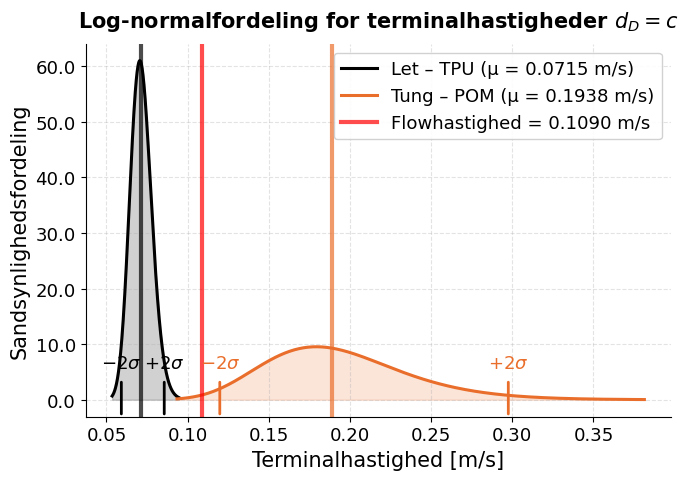

In [5]:
df_light = calculate(data_TPU, rho_p=rho_l, C=C, dD = "c")
df_heavy = calculate(data_POM, rho_p=rho_h, C=C, dD = "c")

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = c$",
    v_experiment=0.109,
)

># 6,3mm 

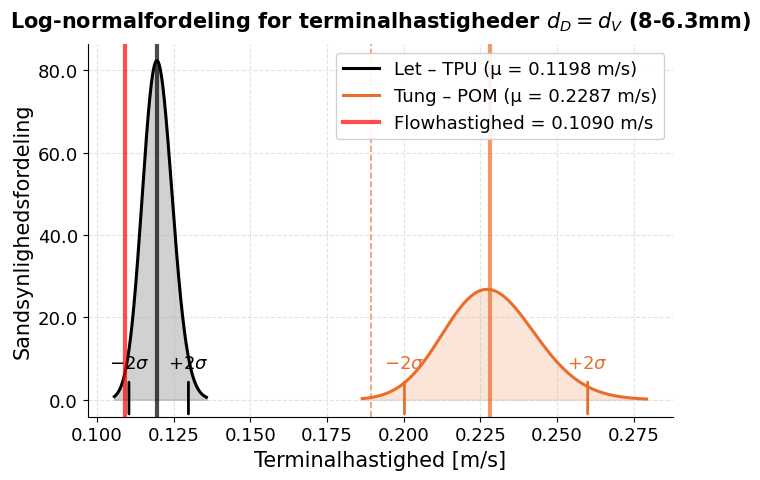

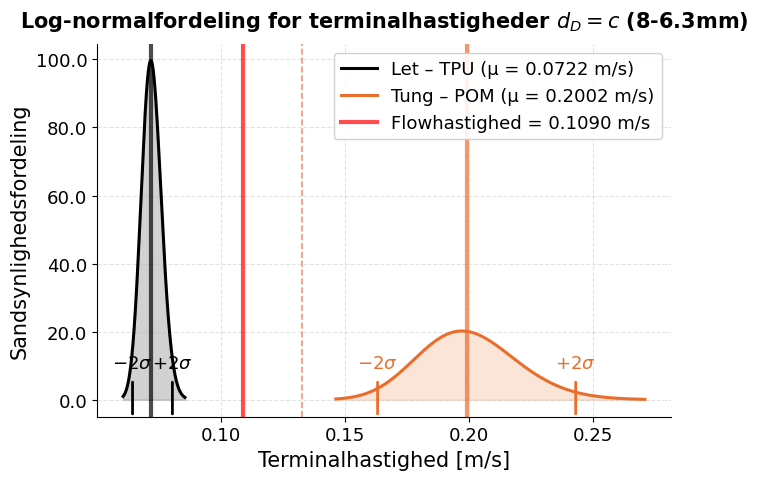

,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
Mean,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.4660,1236.0729,1.1169,0.1328,0.0901,10.4300,8.3600,2.9700,0.1634,0.1086,6.3741,5.9202
Mean,0.4660,1236.0729,1.1169,0.1328,0.0901,10.4300,8.3600,2.9700,0.1634,0.1086,6.3741,5.9202


In [6]:
data_light_p = [      
       
]

data_heavy_p = [                
    [2.97, 8.36, 10.43, 0.1634]
]

df_light = calculate(data_light_6_3, rho_p=rho_l, C=C, dD = "dV"); df_light_p = calculate(data_light_p, rho_p=rho_l, C=C, dD = "dV") if data_light_p else None
df_heavy = calculate(data_heavy_6_3, rho_p=rho_h, C=C, dD = "dV"); df_heavy_p = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "dV") if data_heavy_p else None

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = d_V$ (8-6.3mm)",
    points_light=df_light_p["v_single_m/s"].tolist() if df_light_p is not None else [],
    points_heavy=df_heavy_p["v_single_m/s"].tolist() if df_heavy_p is not None else [],
    v_experiment=0.109,
)

df_light = calculate(data_light_6_3, rho_p=rho_l, C=C, dD = "c"); df_light_p = calculate(data_light_p, rho_p=rho_l, C=C, dD = "c") if data_light_p else None
df_heavy = calculate(data_heavy_6_3, rho_p=rho_h, C=C, dD = "c"); df_heavy_p = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "c") if data_heavy_p else None

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = c$ (8-6.3mm)",
    points_light=df_light_p["v_single_m/s"].tolist() if df_light_p is not None else [],
    points_heavy=df_heavy_p["v_single_m/s"].tolist() if df_heavy_p is not None else [],
    v_experiment=0.109,
)

df_light = calculate(data_light_p, rho_p=rho_l, C=C, dD = "c")
df_heavy = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "c")

cols = ["psi","Re","Cd","v_single_m/s","v_hindered_m/s", "a_mm", "b_mm", "c_mm", "m_gram", "V_cm^3", "dn_mm", "dV_mm"]

for df, label in [(df_light, "LIGHT (POM)"), (df_heavy, "HEAVY (Epoxy)")]:
    d = df[cols].reset_index(drop=True)
    d.index += 1
    d.loc["Mean"] = d.mean()
    styled = (d.style.format("{:.4f}").set_caption(label)
               .set_properties(subset=pd.IndexSlice["Mean", :], **{"font-weight": "bold"}))
    display(styled)

># 4mm

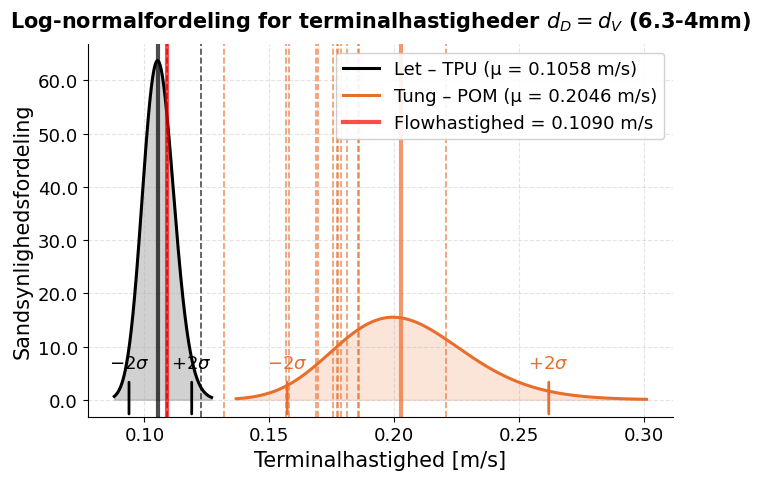

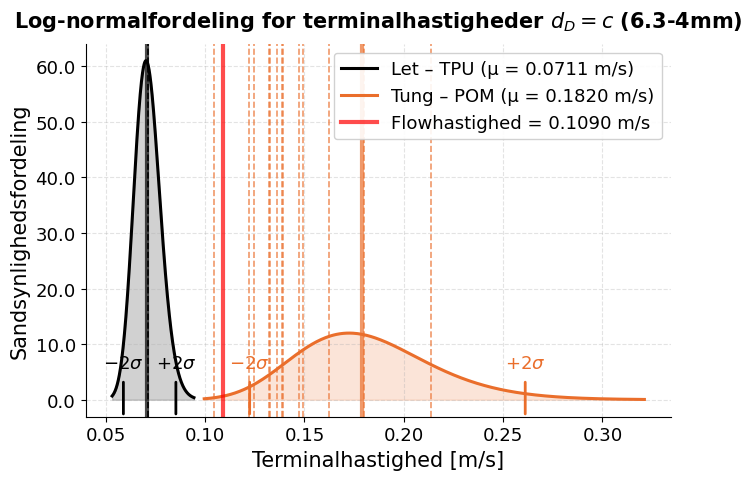

,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.3713,709.6167,1.1652,0.0713,0.0490,17.5600,5.6800,2.2600,0.1657,0.1383,6.0859,6.4164
2,0.4250,585.7036,1.1869,0.0711,0.0485,13.0600,5.2300,2.2900,0.0876,0.0731,5.3880,5.1882
Mean,0.3982,647.6601,1.1760,0.0712,0.0488,15.3100,5.4550,2.2750,0.1266,0.1057,5.7370,5.8023


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.6660,1028.0584,1.1217,0.1491,0.1011,8.2500,5.8000,3.7600,0.1150,0.0765,5.6453,5.2660
2,0.5707,483.7935,1.2116,0.1046,0.0709,5.3000,4.0600,2.0000,0.0233,0.0155,3.5044,3.0929
3,0.5675,1072.0020,1.1276,0.1393,0.0945,10.6600,5.5900,3.3000,0.1300,0.0864,5.8152,5.4857
4,0.6735,955.2180,1.1030,0.1472,0.1022,7.1300,5.9500,3.6000,0.1076,0.0715,5.3453,5.1506
5,0.5009,1110.7944,1.1248,0.1326,0.0899,10.8400,6.5200,2.9800,0.1468,0.0976,5.9497,5.7125
6,0.5447,980.0102,1.1349,0.1322,0.0919,8.5900,6.4400,2.9900,0.1084,0.0721,5.4893,5.1633
7,0.6353,903.3283,1.1419,0.1387,0.0962,8.9000,4.8000,3.3100,0.0885,0.0588,5.2098,4.8258
8,0.9277,953.1694,0.5814,0.2136,0.1484,4.9000,4.0900,4.0000,0.0612,0.0407,4.3118,4.2674
9,0.6238,881.8075,1.1441,0.1362,0.0944,7.9300,5.3200,3.2000,0.0609,0.0405,5.1299,4.2605
10,0.7898,749.2448,0.8180,0.1624,0.1118,5.2300,4.1000,3.2500,0.0471,0.0313,4.1152,3.9107


In [7]:
data_light_p = [
    [2.26, 5.68, 17.56, 0.1657],
    [2.29, 5.23, 13.06, 0.0876]
]

data_heavy_p = [
    [3.76, 5.80, 8.25, 0.1150],
    [2.00, 4.06, 5.30, 0.0233],
    [3.30, 5.59, 10.66, 0.1300],
    [3.60, 5.95, 7.13, 0.1076],
    [2.98, 6.52, 10.84, 0.1468],
    [2.99, 6.44, 8.59, 0.1084],
    [3.31, 4.80, 8.90, 0.0885],
    [4.00, 4.09, 4.90, 0.0612],
    [3.20, 5.32, 7.93, 0.0609],
    [3.25, 4.10, 5.23, 0.0471],
    [3.86, 4.68, 6.35, 0.0552],
    [2.57, 6.62, 7.58, 0.0895],
    [2.74, 5.10, 5.56, 0.0609]
]

df_light = calculate(data_light_4, rho_p=rho_l, C=C, dD = "dV"); df_light_p = calculate(data_light_p, rho_p=rho_l, C=C, dD = "dV") if data_light_p else None
df_heavy = calculate(data_heavy_4, rho_p=rho_h, C=C, dD = "dV"); df_heavy_p = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "dV") if data_heavy_p else None

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = d_V$ (6.3-4mm)",
    points_light=df_light_p["v_single_m/s"].tolist() if df_light_p is not None else [],
    points_heavy=df_heavy_p["v_single_m/s"].tolist() if df_heavy_p is not None else [],
    v_experiment=0.109,
)

df_light = calculate(data_light_4, rho_p=rho_l, C=C, dD = "c"); df_light_p = calculate(data_light_p, rho_p=rho_l, C=C, dD = "c") if data_light_p else None
df_heavy = calculate(data_heavy_4, rho_p=rho_h, C=C, dD = "c"); df_heavy_p = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "c") if data_heavy_p else None

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = c$ (6.3-4mm)",
    points_light=df_light_p["v_single_m/s"].tolist() if df_light_p is not None else [],
    points_heavy=df_heavy_p["v_single_m/s"].tolist() if df_heavy_p is not None else [],
    v_experiment=0.109,
)

df_light = calculate(data_light_p, rho_p=rho_l, C=C, dD = "c")
df_heavy = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "c")

cols = ["psi","Re","Cd","v_single_m/s","v_hindered_m/s", "a_mm", "b_mm", "c_mm", "m_gram", "V_cm^3", "dn_mm", "dV_mm"]

for df, label in [(df_light, "LIGHT (POM)"), (df_heavy, "HEAVY (Epoxy)")]:
    d = df[cols].reset_index(drop=True)
    d.index += 1
    d.loc["Mean"] = d.mean()
    styled = (d.style.format("{:.4f}").set_caption(label)
               .set_properties(subset=pd.IndexSlice["Mean", :], **{"font-weight": "bold"}))
    display(styled)

># 1,8mm


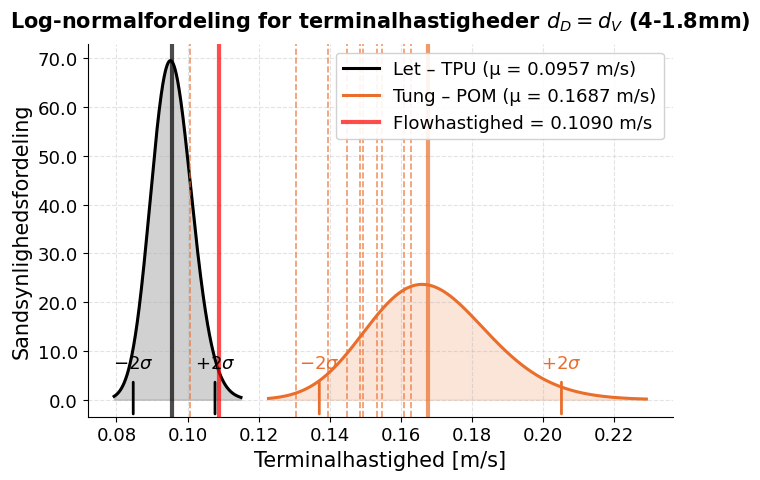

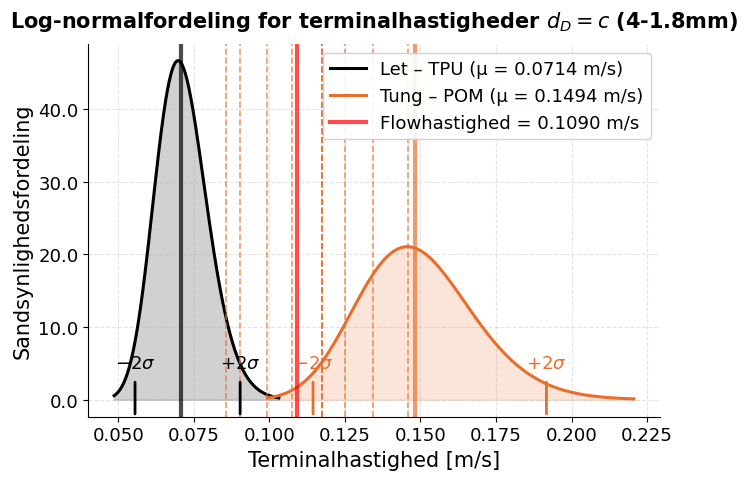

,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
Mean,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.4659,688.0911,1.1685,0.1076,0.0739,8.6100,4.7800,2.0400,0.0681,0.0453,4.3788,4.4222
2,0.6305,577.2722,1.1886,0.1174,0.0801,5.2000,4.6800,2.4700,0.0457,0.0304,3.9173,3.8716
3,0.7647,494.1358,0.9095,0.1342,0.0910,4.4300,3.0800,2.4700,0.0267,0.0178,3.2301,3.2366
4,0.4779,414.4285,1.2344,0.0904,0.0608,5.6900,3.7200,1.5200,0.0223,0.0148,3.1805,3.0480
5,0.4652,551.3171,1.1943,0.0992,0.0675,10.0400,3.1000,1.7700,0.0457,0.0304,3.8050,3.8716
6,0.6492,241.5412,1.3384,0.0857,0.0564,3.3500,2.3900,1.4800,0.0062,0.0041,2.2798,1.9894
7,0.6455,662.7633,1.1726,0.1250,0.0857,7.0800,4.0000,2.7600,0.0534,0.0355,4.2756,4.0779
8,0.6794,499.2677,1.1509,0.1174,0.0796,5.2800,3.4500,2.3900,0.0286,0.0190,3.5179,3.3116
9,0.7027,811.7807,1.0263,0.1458,0.1007,7.4100,4.2100,3.2900,0.0530,0.0352,4.6820,4.0676
10,0.6356,570.0286,1.1902,0.1173,0.0800,7.2000,3.3000,2.4700,0.0394,0.0262,3.8861,3.6848


In [8]:
data_light_p = [
]

data_heavy_p = [
    [2.04, 4.78, 8.61, 0.0681],
    [2.47, 4.68, 5.20, 0.0457],
    [2.47, 3.08, 4.43, 0.0267],
    [1.52, 3.72, 5.69, 0.0223],
    [1.77, 3.10, 10.04, 0.0457],
    [1.48, 2.39, 3.35, 0.0062],
    [2.76, 4.00, 7.08, 0.0534],
    [2.39, 3.45, 5.28, 0.0286],
    [3.29, 4.21, 7.41, 0.0530],
    [2.47, 3.30, 7.20, 0.0394]
]

df_light = calculate(data_light_1_8, rho_p=rho_l, C=C, dD = "dV"); df_light_p = calculate(data_light_p, rho_p=rho_l, C=C, dD = "dV") if data_light_p else None
df_heavy = calculate(data_heavy_1_8, rho_p=rho_h, C=C, dD = "dV"); df_heavy_p = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "dV") if data_heavy_p else None

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = d_V$ (4-1.8mm)",
    points_light=df_light_p["v_single_m/s"].tolist() if df_light_p is not None else [],
    points_heavy=df_heavy_p["v_single_m/s"].tolist() if df_heavy_p is not None else [],
    v_experiment=0.109,
)

df_light = calculate(data_light_1_8, rho_p=rho_l, C=C, dD = "c"); df_light_p = calculate(data_light_p, rho_p=rho_l, C=C, dD = "c") if data_light_p else None
df_heavy = calculate(data_heavy_1_8, rho_p=rho_h, C=C, dD = "c"); df_heavy_p = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "c") if data_heavy_p else None

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = c$ (4-1.8mm)",
    points_light=df_light_p["v_single_m/s"].tolist() if df_light_p is not None else [],
    points_heavy=df_heavy_p["v_single_m/s"].tolist() if df_heavy_p is not None else [],
    v_experiment=0.109,
)


df_light = calculate(data_light_p, rho_p=rho_l, C=C, dD = "c")
df_heavy = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "c")

cols = ["psi","Re","Cd","v_single_m/s","v_hindered_m/s", "a_mm", "b_mm", "c_mm", "m_gram", "V_cm^3", "dn_mm", "dV_mm"]

for df, label in [(df_light, "LIGHT (POM)"), (df_heavy, "HEAVY (Epoxy)")]:
    d = df[cols].reset_index(drop=True)
    d.index += 1
    d.loc["Mean"] = d.mean()
    styled = (d.style.format("{:.4f}").set_caption(label)
               .set_properties(subset=pd.IndexSlice["Mean", :], **{"font-weight": "bold"}))
    display(styled)

# Renhed og udbytte (andel-baseret)

In [9]:
# === Renhed og udbytte (ANDEL-baseret) ===
# Beregnet ud fra den fittede log-normalfordeling af v_single (samme data som
# fordelingsplottene). En partikel synker til underflow hvis v_single > v_flow,
# ellers loftes den til overflow. Renhed og udbytte er ANDELE (areal under
# fordelingen), ikke masse. Renheden forudsaetter samme udgangsandel af hvert
# materiale; den reelle masse-renhed afhaenger af blandingsforholdet.
import numpy as np
from scipy.stats import lognorm

def _fit_ln(vals):
    vals = np.asarray(vals, dtype=float)
    shape, loc, scale = lognorm.fit(vals, floc=0)
    return shape, scale

def renhed_udbytte(v_light, v_heavy, v_flow):
    """light loftes (overflow) hvis v < v_flow ; heavy synker (underflow) hvis v > v_flow."""
    sL, scL = _fit_ln(v_light)
    sH, scH = _fit_ln(v_heavy)
    light_over = lognorm.cdf(v_flow, sL, 0, scL)   # let i overflow (korrekt)
    heavy_over = lognorm.cdf(v_flow, sH, 0, scH)    # tung i overflow (forkert)
    light_under = 1 - light_over                    # let i underflow (forkert)
    heavy_under = 1 - heavy_over                     # tung i underflow (korrekt)
    return {
        "Overflow renhed %":   100*light_over /(light_over + heavy_over),
        "Overflow udbytte %":  100*light_over,
        "Underflow renhed %":  100*heavy_under/(heavy_under + light_under),
        "Underflow udbytte %": 100*heavy_under,
    }

def vis(label, v_light, v_heavy, v_flow):
    r = renhed_udbytte(v_light, v_heavy, v_flow)
    print(f"{label}  (v_flow = {v_flow} m/s)")
    print(f"   Overflow  (let):   renhed {r['Overflow renhed %']:6.1f} %   udbytte {r['Overflow udbytte %']:6.1f} %")
    print(f"   Underflow (tung):  renhed {r['Underflow renhed %']:6.1f} %   udbytte {r['Underflow udbytte %']:6.1f} %")
    print()
    return r

# --- Intralox (TPU/POM): tre fraktioner, begge diametre ---
fraktioner = [
    ("8-6,3 mm", data_light_6_3, data_heavy_6_3, 0.109),
    ("6,3-4 mm", data_light_4,   data_heavy_4,   0.109),
    ("4-1,8 mm", data_light_1_8, data_heavy_1_8, 0.109),
]
for navn, L, H, vf in fraktioner:
    for dD in ["c", "dV"]:
        vL = calculate(L, rho_p=rho_l, C=C, dD=dD)["v_single_m/s"].values
        vH = calculate(H, rho_p=rho_h, C=C, dD=dD)["v_single_m/s"].values
        vis(f"Intralox | {navn} | d_D = {dD}", vL, vH, vf)


Intralox | 8-6,3 mm | d_D = c  (v_flow = 0.109 m/s)
   Overflow  (let):   renhed  100.0 %   udbytte  100.0 %
   Underflow (tung):  renhed  100.0 %   udbytte  100.0 %

Intralox | 8-6,3 mm | d_D = dV  (v_flow = 0.109 m/s)
   Overflow  (let):   renhed  100.0 %   udbytte    0.9 %
   Underflow (tung):  renhed   50.2 %   udbytte  100.0 %

Intralox | 6,3-4 mm | d_D = c  (v_flow = 0.109 m/s)
   Overflow  (let):   renhed   99.6 %   udbytte  100.0 %
   Underflow (tung):  renhed  100.0 %   udbytte   99.6 %

Intralox | 6,3-4 mm | d_D = dV  (v_flow = 0.109 m/s)
   Overflow  (let):   renhed  100.0 %   udbytte   70.6 %
   Underflow (tung):  renhed   77.3 %   udbytte  100.0 %

Intralox | 4-1,8 mm | d_D = c  (v_flow = 0.109 m/s)
   Overflow  (let):   renhed   99.2 %   udbytte  100.0 %
   Underflow (tung):  renhed  100.0 %   udbytte   99.2 %

Intralox | 4-1,8 mm | d_D = dV  (v_flow = 0.109 m/s)
   Overflow  (let):   renhed  100.0 %   udbytte   98.7 %
   Underflow (tung):  renhed   98.8 %   udbytte  100.

# Teoretisk optimal separation

In [10]:
# === Teoretisk optimal separation (andel-baseret) ===
# Finder den flowhastighed der MAKSIMERER det samlede udbytte (let op + tung ned).
# Dette er den teoretiske oevre graense givet fordelingernes overlap.
# Renhed og udbytte er andele, ikke masse.
import numpy as np
from scipy.stats import lognorm

def _fit_ln(vals):
    vals = np.asarray(vals, dtype=float)
    shape, loc, scale = lognorm.fit(vals, floc=0)
    return shape, scale

def optimal_separation(v_light, v_heavy, n=4000):
    sL, scL = _fit_ln(v_light)
    sH, scH = _fit_ln(v_heavy)
    lo = min(v_light.min(), v_heavy.min())
    hi = max(v_light.max(), v_heavy.max())
    flows = np.linspace(lo, hi, n)
    best = None
    for f in flows:
        light_over = lognorm.cdf(f, sL, 0, scL)      # let i overflow (udbytte)
        heavy_under = 1 - lognorm.cdf(f, sH, 0, scH)  # tung i underflow (udbytte)
        tot = light_over + heavy_under
        if best is None or tot > best[0]:
            heavy_over  = lognorm.cdf(f, sH, 0, scH)
            light_under = 1 - light_over
            ren_over  = light_over  / (light_over + heavy_over)
            ren_under = heavy_under / (heavy_under + light_under)
            best = (tot, f, light_over, heavy_under, ren_over, ren_under)
    _, f, lo_u, hu, ro, ru = best
    return {"v_optimal": f, "Overflow renhed %": 100*ro, "Overflow udbytte %": 100*lo_u,
            "Underflow renhed %": 100*ru, "Underflow udbytte %": 100*hu}

def vis_optimal(navn, v_light, v_heavy):
    r = optimal_separation(v_light, v_heavy)
    print(f"{navn}: optimal flowhastighed = {r['v_optimal']:.3f} m/s")
    print(f"   Overflow  (let):   renhed {r['Overflow renhed %']:5.1f} %   udbytte {r['Overflow udbytte %']:5.1f} %")
    print(f"   Underflow (tung):  renhed {r['Underflow renhed %']:5.1f} %   udbytte {r['Underflow udbytte %']:5.1f} %")
    print()
    return r

# TPU-POM: tre fraktioner (TPU let -> overflow, POM tung -> underflow)
fraktioner_opt = [
    ("8-6,3 mm", data_light_6_3, data_heavy_6_3),
    ("6,3-4 mm", data_light_4,   data_heavy_4),
    ("4-1,8 mm", data_light_1_8, data_heavy_1_8),
]
for navn, L, H in fraktioner_opt:
    vL = calculate(L, rho_p=rho_l, C=C, dD="c")["v_single_m/s"].values
    vH = calculate(H, rho_p=rho_h, C=C, dD="c")["v_single_m/s"].values
    vis_optimal(f"TPU-POM | {navn} | d_D = c", vL, vH)


TPU-POM | 8-6,3 mm | d_D = c: optimal flowhastighed = 0.104 m/s
   Overflow  (let):   renhed 100.0 %   udbytte 100.0 %
   Underflow (tung):  renhed 100.0 %   udbytte 100.0 %

TPU-POM | 6,3-4 mm | d_D = c: optimal flowhastighed = 0.097 m/s
   Overflow  (let):   renhed  99.9 %   udbytte 100.0 %
   Underflow (tung):  renhed 100.0 %   udbytte  99.9 %

TPU-POM | 4-1,8 mm | d_D = c: optimal flowhastighed = 0.101 m/s
   Overflow  (let):   renhed  99.9 %   udbytte  99.9 %
   Underflow (tung):  renhed  99.9 %   udbytte  99.9 %

